# 05. Retrieval Ablation

## 분석 목적

이번 분석의 핵심 질문은 다음과 같다.

1. 흔한 Note보다 희귀한 Note에 높은 정보량을 주면 추천 성능이 개선되는가?
2. 흔한 Accord보다 희귀한 Accord의 영향력을 높이면 추천 성능이 개선되는가?
3. Accord와 Notes의 결합 비율 0.5 : 0.5가 적절한가?
4. 개선 결과가 특정 인기 향수 구간에만 집중되는가?

이번 단계에서는 기존 Baseline의 각 요소를 하나씩 검증한다. Season, Daypart, Community Gender,
Longevity, Sillage, Note 위치 가중치, LLM, Embedding은 추가하지 않는다. `reminds_me_of`는 오직
Relevant Item 평가 label로만 사용하며 similarity 계산에는 사용하지 않는다. Final Holdout 300개는
분할 재현 여부만 확인하고 어떤 추천이나 성능 평가에도 사용하지 않는다.

## 1. 환경 설정

전체 131,930 × 131,930 similarity matrix를 만들지 않는다. 평가 query의 작은 batch와 전체 후보 간
점수만 잠시 계산하고, 각 query의 TOP 20만 보관한다. 오래 걸리는 반복에는 `tqdm`을 사용한다.

In [1]:
import array
import collections
import gc
import json
import math
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from tqdm.auto import tqdm

SEED = 42
MAX_K = 20
BATCH_SIZE = 16
MIN_GROUP_SIZE = 20
BOOTSTRAP_RESAMPLES = 2000

jsonl_path = pathlib.Path.cwd() / "perfumes.jsonl"
assert jsonl_path.is_file(), f"파일을 찾을 수 없습니다: {jsonl_path}"
print(f"데이터: {jsonl_path.name} ({jsonl_path.stat().st_size / (1024 ** 2):,.2f} MB)")

데이터: perfumes.jsonl (485.94 MB)


## 2. 데이터 로드

04 Notebook과 동일하게 id, 이름, 브랜드, `popularity.magnitude`, 92개 Accord strength,
top/middle/base/flat 위치를 구분하지 않은 Note union, `similar.reminds_me_of` 투표만 스트리밍으로 읽는다.
원본 파일은 수정하지 않는다.

In [2]:
perfume_ids = array.array("i")
perfume_names, perfume_brands = [], []
popularity_values = array.array("f")
has_accord, has_note = array.array("b"), array.array("b")

accord_to_col = {}
accord_rows, accord_cols, accord_data = array.array("I"), array.array("I"), array.array("f")
note_to_col = {}
note_rows, note_cols = array.array("I"), array.array("I")

relation_source_ids, relation_target_ids = array.array("i"), array.array("i")
relation_up_votes, relation_down_votes = array.array("i"), array.array("i")

with jsonl_path.open("r", encoding="utf-8") as file:
    for line in tqdm(file, desc="JSONL load", unit=" perfumes"):
        if not line.strip():
            continue
        row_index = len(perfume_ids)
        record = json.loads(line)
        perfume_id = int(record["id"])
        perfume_ids.append(perfume_id)
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

        accord_strengths = {}
        for item in record.get("accords") or []:
            name, strength = item.get("name"), item.get("strength")
            if name and strength is not None:
                col = accord_to_col.setdefault(name, len(accord_to_col))
                accord_strengths[col] = float(strength)
        has_accord.append(bool(accord_strengths))
        for col, strength in accord_strengths.items():
            accord_rows.append(row_index)
            accord_cols.append(col)
            accord_data.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        note_names = set()
        for position in ("top", "middle", "base"):
            note_names.update(
                item.get("name") for item in tiered.get(position) or [] if item.get("name")
            )
        note_names.update(item.get("name") for item in notes.get("flat") or [] if item.get("name"))
        note_columns = {note_to_col.setdefault(name, len(note_to_col)) for name in note_names}
        has_note.append(bool(note_columns))
        for col in note_columns:
            note_rows.append(row_index)
            note_cols.append(col)

        for relation in (record.get("similar") or {}).get("reminds_me_of") or []:
            target_id = relation.get("id")
            up_votes, down_votes = relation.get("up_votes"), relation.get("down_votes")
            relation_source_ids.append(perfume_id)
            relation_target_ids.append(int(target_id) if target_id is not None else -1)
            relation_up_votes.append(int(up_votes) if up_votes is not None else -1)
            relation_down_votes.append(int(down_votes) if down_votes is not None else -1)

perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity = np.asarray(popularity_values, dtype=np.float32)
has_accord, has_note = np.asarray(has_accord, dtype=bool), np.asarray(has_note, dtype=bool)
id_to_row = {int(perfume_id): row for row, perfume_id in enumerate(perfume_ids)}
n_perfumes = len(perfume_ids)

print(f"향수 수: {n_perfumes:,}")
print(f"고유 Accord 수: {len(accord_to_col):,}")
print(f"고유 Note 수: {len(note_to_col):,}")
print(f"directed reminds_me_of 수: {len(relation_source_ids):,}")
assert len(accord_to_col) == 92, "04 Notebook의 92개 Accord 구조와 다릅니다."

JSONL load: 0 perfumes [00:00, ? perfumes/s]

향수 수: 131,930
고유 Accord 수: 92
고유 Note 수: 2,523
directed reminds_me_of 수: 692,729


## 3. 04 Notebook 평가 데이터 재현

양방향 투표를 unordered pair 단위로 합산한 뒤 `total_votes >= 20 AND agree_ratio >= 0.8`을
Relevant Pair로 사용한다. Query는 relevant item이 2개 이상이며 Accord와 Note가 모두 있어야 한다.
seed 42로 1,000개를 선택하고, 별도의 seed 42 permutation으로 Development 700 / Final Holdout 300을 만든다.

In [3]:
directed_relations = pd.DataFrame({
    "source_id": np.asarray(relation_source_ids, dtype=np.int32),
    "target_id": np.asarray(relation_target_ids, dtype=np.int32),
    "up_votes": np.asarray(relation_up_votes, dtype=np.int32),
    "down_votes": np.asarray(relation_down_votes, dtype=np.int32),
})
valid = directed_relations[
    (directed_relations["source_id"] > 0)
    & (directed_relations["target_id"] > 0)
    & (directed_relations["up_votes"] >= 0)
    & (directed_relations["down_votes"] >= 0)
].copy()
valid["pair_low"] = np.minimum(valid["source_id"], valid["target_id"])
valid["pair_high"] = np.maximum(valid["source_id"], valid["target_id"])
pair_relations = valid.groupby(["pair_low", "pair_high"], sort=False, as_index=False)[
    ["up_votes", "down_votes"]
].sum()
pair_relations["total_votes"] = pair_relations["up_votes"] + pair_relations["down_votes"]
pair_relations["agree_ratio"] = np.divide(
    pair_relations["up_votes"], pair_relations["total_votes"],
    out=np.full(len(pair_relations), np.nan),
    where=pair_relations["total_votes"].to_numpy() > 0,
)
relevant_pairs_all = pair_relations[
    (pair_relations["pair_low"] != pair_relations["pair_high"])
    & (pair_relations["total_votes"] >= 20)
    & (pair_relations["agree_ratio"] >= 0.8)
].copy()
inside_mask = (
    relevant_pairs_all["pair_low"].isin(id_to_row)
    & relevant_pairs_all["pair_high"].isin(id_to_row)
)
relevant_pairs = relevant_pairs_all.loc[inside_mask].copy()

relevant_by_query = collections.defaultdict(set)
for low, high in relevant_pairs[["pair_low", "pair_high"]].itertuples(index=False, name=None):
    low, high = int(low), int(high)
    relevant_by_query[low].add(high)
    relevant_by_query[high].add(low)

eligible_query_ids = np.array(sorted(
    query_id for query_id, items in relevant_by_query.items()
    if len(items) >= 2 and has_accord[id_to_row[query_id]] and has_note[id_to_row[query_id]]
), dtype=np.int32)

selection_rng = np.random.default_rng(SEED)
selected_query_ids = selection_rng.choice(eligible_query_ids, size=1000, replace=False)
split_rng = np.random.default_rng(SEED)
selected_query_ids = split_rng.permutation(selected_query_ids)
development_query_ids = selected_query_ids[:700]
final_holdout_query_ids = selected_query_ids[700:]

assert len(development_query_ids) == 700 and len(final_holdout_query_ids) == 300
assert set(development_query_ids).isdisjoint(final_holdout_query_ids)

reproduction_summary = pd.Series({
    "Relevant Pair 수": len(relevant_pairs_all),
    "평가 가능 Query 수": len(eligible_query_ids),
    "Development 수": len(development_query_ids),
    "Final Holdout 수": len(final_holdout_query_ids),
})
display(reproduction_summary.to_frame("값"))
print("Development Query ID 앞 10개:", development_query_ids[:10].tolist())
print("Final Holdout Query ID 앞 10개:", final_holdout_query_ids[:10].tolist())
print("Final Holdout은 아래의 추천/평가 함수에 전달하지 않습니다.")

del directed_relations, valid, pair_relations, relevant_pairs, relevant_pairs_all
del relation_source_ids, relation_target_ids, relation_up_votes, relation_down_votes
gc.collect()

,값
Relevant Pair 수,10770
평가 가능 Query 수,3835
Development 수,700
Final Holdout 수,300


Development Query ID 앞 10개: [68393, 93820, 40155, 16220, 109598, 57684, 5634, 19669, 48389, 71291]
Final Holdout Query ID 앞 10개: [40468, 8894, 1658, 51250, 12112, 55166, 85084, 113714, 87451, 33253]
Final Holdout은 아래의 추천/평가 함수에 전달하지 않습니다.


40

## 4. Development 내부 분리

기존 Development 700개를 seed 42의 새 permutation으로 Tuning 500 / Internal Validation 200으로 나눈다.
Feature 방식과 alpha는 Tuning에서만 선택하고, 선택 완료 뒤 Validation에서는 Baseline과 선택 모델만 비교한다.
Validation 결과를 보고 feature나 alpha를 다시 바꾸지 않는다.

In [4]:
development_split_rng = np.random.default_rng(SEED)
development_permuted = development_split_rng.permutation(development_query_ids)
tuning_query_ids = development_permuted[:500]
validation_query_ids = development_permuted[500:]

assert len(tuning_query_ids) == 500 and len(validation_query_ids) == 200
assert set(tuning_query_ids).isdisjoint(validation_query_ids)
assert set(tuning_query_ids) | set(validation_query_ids) == set(development_query_ids)

pd.Series({
    "Tuning": len(tuning_query_ids),
    "Internal Validation": len(validation_query_ids),
    "Final Holdout (미사용)": len(final_holdout_query_ids),
}).to_frame("Query 수")

,Query 수
Tuning,500
Internal Validation,200
Final Holdout (미사용),300


## 5. Sparse feature matrix와 빈도 분석

Note/Accord document frequency는 전체 추천 후보 향수 `N=131,930`을 기준으로 계산한다.
`idf = log((N + 1) / (df + 1)) + 1`을 사용한다.

In [5]:
X_accord_raw = sparse.csr_matrix(
    (np.asarray(accord_data, dtype=np.float32),
     (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32))),
    shape=(n_perfumes, len(accord_to_col)), dtype=np.float32,
)
X_notes = sparse.csr_matrix(
    (np.ones(len(note_rows), dtype=np.float32),
     (np.asarray(note_rows, dtype=np.int32), np.asarray(note_cols, dtype=np.int32))),
    shape=(n_perfumes, len(note_to_col)), dtype=np.float32,
)

def row_normalize(matrix):
    norms = np.sqrt(matrix.multiply(matrix).sum(axis=1)).A1.astype(np.float32)
    inverse = np.zeros_like(norms)
    np.divide(1.0, norms, out=inverse, where=norms > 0)
    return matrix.multiply(inverse[:, None]).tocsr()

note_df = np.asarray((X_notes > 0).sum(axis=0)).ravel().astype(np.int32)
accord_df = np.asarray((X_accord_raw > 0).sum(axis=0)).ravel().astype(np.int32)
note_idf = (np.log((n_perfumes + 1) / (note_df + 1)) + 1).astype(np.float32)
accord_idf = (np.log((n_perfumes + 1) / (accord_df + 1)) + 1).astype(np.float32)

X_accord = row_normalize(X_accord_raw)
X_accord_idf = row_normalize(X_accord_raw.multiply(accord_idf).tocsr())
X_note_weighted = X_notes.multiply(note_idf).tocsr()
note_counts = np.asarray(X_notes.sum(axis=1)).ravel().astype(np.float32)
note_weight_sums = np.asarray(X_note_weighted.sum(axis=1)).ravel().astype(np.float32)

col_to_note = {col: name for name, col in note_to_col.items()}
note_frequency_df = pd.DataFrame({
    "note": [col_to_note[i] for i in range(len(col_to_note))], "df": note_df, "idf": note_idf,
})
display(pd.Series({
    "전체 Note 수": len(note_frequency_df),
    "df 중앙값": float(np.median(note_df)),
    "df 75%": float(np.quantile(note_df, 0.75)),
    "df 90%": float(np.quantile(note_df, 0.90)),
    "df 95%": float(np.quantile(note_df, 0.95)),
    "df 99%": float(np.quantile(note_df, 0.99)),
}).to_frame("값"))
display(Markdown("**가장 흔한 Note TOP 20**"))
display(note_frequency_df.sort_values(["df", "note"], ascending=[False, True]).head(20).reset_index(drop=True))
display(Markdown("**가장 희귀한 Note 중 df >= 10인 예시 20개**"))
display(note_frequency_df[note_frequency_df["df"] >= 10]
        .sort_values(["df", "note"]).head(20).reset_index(drop=True))

col_to_accord = {col: name for name, col in accord_to_col.items()}
accord_frequency_df = pd.DataFrame({
    "accord": [col_to_accord[i] for i in range(len(col_to_accord))], "df": accord_df, "idf": accord_idf,
})
display(Markdown("**Accord document frequency와 IDF**"))
display(accord_frequency_df.sort_values(["df", "accord"], ascending=[False, True]).reset_index(drop=True))

print(f"Raw Accord matrix: {X_accord.shape}, nnz={X_accord.nnz:,}")
print(f"Note matrix: {X_notes.shape}, nnz={X_notes.nnz:,}")
del X_accord_raw, accord_rows, accord_cols, accord_data, note_rows, note_cols
gc.collect()

,값
전체 Note 수,2523.00
df 중앙값,14.00
df 75%,76.00
df 90%,576.80
df 95%,1598.40
df 99%,8260.84


**가장 흔한 Note TOP 20**

,note,df,idf
0,Musk,49244,1.985471
1,Amber,36671,2.280266
2,Bergamot,36337,2.289415
3,Vanilla,35628,2.309119
4,Sandalwood,34292,2.347338
5,Jasmine,33686,2.365167
6,Patchouli,32473,2.401839
7,Rose,27804,2.557063
8,Cedar,22305,2.777423
9,Vetiver,17674,3.010128


**가장 희귀한 Note 중 df >= 10인 예시 20개**

,note,df,idf
0,Amazon Lily,10,10.392139
1,Assam Tea,10,10.392139
2,Beer/Ale,10,10.392139
3,Blackberry Blossom,10,10.392139
4,Caffè Latte,10,10.392139
5,Caipirinha,10,10.392139
6,Canadian Pine,10,10.392139
7,Chalood Bark,10,10.392139
8,Cherimoya,10,10.392139
9,China Rose,10,10.392139


**Accord document frequency와 IDF**

,accord,df,idf
0,woody,81432,1.482498
1,powdery,62885,1.740955
2,sweet,60625,1.777555
3,citrus,59969,1.788435
4,aromatic,54606,1.882117
...,...,...,...
87,bbq,3,11.403740
88,tennis ball,3,11.403740
89,wet plaster,2,11.691422
90,brown scotch tape,1,12.096888


Raw Accord matrix: (131930, 92), nnz=1,000,570
Note matrix: (131930, 2523), nnz=1,091,811


40

## 6. Similarity와 평가 함수

- Raw Accord: `accord_strength` cosine similarity
- IDF Accord: `accord_strength × accord_idf` cosine similarity
- Raw Note: 위치 구분 없는 union set Jaccard
- IDF Note: 교집합 IDF 합 / 합집합 IDF 합

두 Note set이 모두 비면 Weighted Jaccard는 NaN이다. 평가 query는 Note를 가지므로 현재 실험의 query-candidate
점수에서 이 경우는 발생하지 않지만, 함수 자체는 명시적으로 NaN을 반환한다.

In [6]:
def top_k_rows(score_vector, k=MAX_K):
    scores = np.nan_to_num(np.asarray(score_vector), nan=-np.inf)
    k = min(k, scores.size - 1)
    preliminary = np.argpartition(-scores, kth=k - 1)[:k]
    threshold = scores[preliminary].min()
    higher_rows = np.flatnonzero(scores > threshold)
    tied_rows = np.flatnonzero(scores == threshold)
    needed = k - len(higher_rows)
    if needed < len(tied_rows):
        tied_rows = tied_rows[np.argpartition(perfume_ids[tied_rows], needed - 1)[:needed]]
    candidate_rows = np.concatenate([higher_rows, tied_rows[:needed]])
    order = np.lexsort((perfume_ids[candidate_rows], -scores[candidate_rows]))
    return candidate_rows[order].astype(np.int32, copy=False)

def similarity_batch(query_rows):
    raw_accord = (X_accord[query_rows] @ X_accord.T).toarray().astype(np.float32, copy=False)
    idf_accord = (X_accord_idf[query_rows] @ X_accord_idf.T).toarray().astype(np.float32, copy=False)

    raw_intersection = (X_notes[query_rows] @ X_notes.T).toarray()
    raw_union = note_counts[query_rows, None] + note_counts[None, :] - raw_intersection
    raw_note = np.full(raw_intersection.shape, np.nan, dtype=np.float32)
    np.divide(raw_intersection, raw_union, out=raw_note, where=raw_union > 0)

    weighted_intersection = (X_note_weighted[query_rows] @ X_notes.T).toarray()
    weighted_union = note_weight_sums[query_rows, None] + note_weight_sums[None, :] - weighted_intersection
    idf_note = np.full(weighted_intersection.shape, np.nan, dtype=np.float32)
    np.divide(weighted_intersection, weighted_union, out=idf_note, where=weighted_union > 0)
    return raw_accord, idf_accord, raw_note, idf_note

def query_metric_values(recommended_rows, relevant_ids, k):
    relevance = np.fromiter(
        (int(candidate_id) in relevant_ids for candidate_id in perfume_ids[recommended_rows[:k]]),
        dtype=np.int8, count=min(k, len(recommended_rows)),
    )
    hits = int(relevance.sum())
    hit_positions = np.flatnonzero(relevance)
    discounts = 1.0 / np.log2(np.arange(2, len(relevance) + 2))
    ideal_length = min(len(relevant_ids), k)
    idcg = float(discounts[:ideal_length].sum())
    return {
        "recall": hits / len(relevant_ids),
        "hit_rate": float(hits > 0),
        "mrr": 1.0 / (hit_positions[0] + 1) if hit_positions.size else 0.0,
        "ndcg": float(np.dot(relevance, discounts)) / idcg if idcg > 0 else 0.0,
    }

def evaluate_rankings(rankings, query_ids, ks=(5, 10, 20)):
    rows = []
    for query_id in query_ids:
        query_id = int(query_id)
        for k in ks:
            values = query_metric_values(rankings[query_id], relevant_by_query[query_id], k)
            rows.append({"query_id": query_id, "k": k, **values})
    per_query = pd.DataFrame(rows)
    summary = {}
    for k in ks:
        part = per_query[per_query["k"] == k]
        summary.update({
            f"Recall@{k}": part["recall"].mean(),
            f"HitRate@{k}": part["hit_rate"].mean(),
            f"MRR@{k}": part["mrr"].mean(),
            f"NDCG@{k}": part["ndcg"].mean(),
        })
    return summary, per_query

## 7. Tuning: 단일 feature와 0.5/0.5 Ablation

Tuning 500개에서 Raw/IDF Note, Raw/IDF Accord 단독 성능과 네 가지 0.5/0.5 결합을 동시에 계산한다.

In [7]:
single_rankings = {name: {} for name in ("Raw Note", "IDF Note", "Raw Accord", "IDF Accord")}
ablation_names = (
    "Raw Accord + Raw Note", "IDF Accord + Raw Note",
    "Raw Accord + IDF Note", "IDF Accord + IDF Note",
)
ablation_rankings = {name: {} for name in ablation_names}
tuning_rows = np.array([id_to_row[int(q)] for q in tuning_query_ids], dtype=np.int32)

for start in tqdm(range(0, len(tuning_rows), BATCH_SIZE), desc="Tuning ablation"):
    query_rows = tuning_rows[start:start + BATCH_SIZE]
    query_ids = tuning_query_ids[start:start + BATCH_SIZE]
    raw_a, idf_a, raw_n, idf_n = similarity_batch(query_rows)
    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        score_map = {
            "Raw Note": raw_n[i], "IDF Note": idf_n[i],
            "Raw Accord": raw_a[i], "IDF Accord": idf_a[i],
            "Raw Accord + Raw Note": 0.5 * raw_a[i] + 0.5 * raw_n[i],
            "IDF Accord + Raw Note": 0.5 * idf_a[i] + 0.5 * raw_n[i],
            "Raw Accord + IDF Note": 0.5 * raw_a[i] + 0.5 * idf_n[i],
            "IDF Accord + IDF Note": 0.5 * idf_a[i] + 0.5 * idf_n[i],
        }
        for model_name, scores in score_map.items():
            scores[query_row] = -np.inf
            target = single_rankings if model_name in single_rankings else ablation_rankings
            target[model_name][query_id] = top_k_rows(scores, MAX_K)
    del raw_a, idf_a, raw_n, idf_n

single_rows, single_per_query = [], {}
for model_name, model_rankings in single_rankings.items():
    summary, detail = evaluate_rankings(model_rankings, tuning_query_ids, ks=(10, 20))
    single_per_query[model_name] = detail
    single_rows.append({"model": model_name, **summary})
single_results_df = pd.DataFrame(single_rows)
display(single_results_df[["model", "Recall@10", "HitRate@10", "MRR@10", "NDCG@10", "Recall@20", "NDCG@20"]].round(4))

ablation_rows, ablation_per_query = [], {}
for model_name, model_rankings in ablation_rankings.items():
    summary, detail = evaluate_rankings(model_rankings, tuning_query_ids, ks=(10, 20))
    ablation_per_query[model_name] = detail
    ablation_rows.append({"model": model_name, **summary})
tuning_ablation_df = pd.DataFrame(ablation_rows)[
    ["model", "Recall@10", "HitRate@10", "MRR@10", "NDCG@10", "Recall@20", "NDCG@20"]
]
display(Markdown("### 표 1 — Tuning Ablation"))
display(tuning_ablation_df.round(4))

# 결합 representation 선택 기준도 weight 선택과 일관되게 NDCG@10, Recall@10, MRR@10 순으로 둔다.
selected_feature_row = tuning_ablation_df.sort_values(
    ["NDCG@10", "Recall@10", "MRR@10", "model"],
    ascending=[False, False, False, True],
).iloc[0]
selected_feature_model = selected_feature_row["model"]
use_idf_accord = selected_feature_model.startswith("IDF Accord")
use_idf_note = selected_feature_model.endswith("IDF Note")
print("Tuning Set에서 선택된 후보 feature 표현:", selected_feature_model)

Tuning ablation:   0%|          | 0/32 [00:00<?, ?it/s]

,model,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,Raw Note,0.2548,0.494,0.3435,0.2372,0.2868,0.2490
1,IDF Note,0.2572,0.502,0.3355,0.2344,0.3047,0.2511
2,Raw Accord,0.1851,0.402,0.2565,0.1692,0.2218,0.1810
3,IDF Accord,0.1792,0.392,0.2571,0.1676,0.2208,0.1809


### 표 1 — Tuning Ablation

,model,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,Raw Accord + Raw Note,0.2842,0.538,0.3871,0.2671,0.3350,0.2854
1,IDF Accord + Raw Note,0.2774,0.534,0.3793,0.2603,0.3263,0.2776
2,Raw Accord + IDF Note,0.2906,0.546,0.3841,0.2688,0.3394,0.2864
3,IDF Accord + IDF Note,0.2767,0.532,0.3760,0.2592,0.3259,0.2766


Tuning Set에서 선택된 후보 feature 표현: Raw Accord + IDF Note


## 8. Tuning: Accord / Note 결합 가중치 탐색

7절에서 선택된 feature 표현을 고정하고 `combined = alpha × note + (1-alpha) × accord`를 계산한다.
PRIMARY metric은 NDCG@10이며 동률이면 Recall@10, MRR@10 순으로 tie-break한다. 완전 동률이면 재현성을
위해 더 작은 alpha를 택한다. 여기서 얻는 값은 **최종 가중치**가 아니라 **Tuning Set에서 선택된 후보 가중치**다.

Alpha search:   0%|          | 0/32 [00:00<?, ?it/s]

,alpha,Recall@10,HitRate@10,MRR@10,NDCG@10
0,0.0,0.1851,0.402,0.2565,0.1692
1,0.1,0.2319,0.468,0.3358,0.2230
2,0.2,0.2523,0.498,0.3667,0.2451
3,0.3,0.2729,0.530,0.3772,0.2590
4,0.4,0.2779,0.532,0.3831,0.2630
5,0.5,0.2906,0.546,0.3841,0.2688
6,0.6,0.2850,0.536,0.3775,0.2643
7,0.7,0.2806,0.528,0.3645,0.2574
8,0.8,0.2768,0.526,0.3603,0.2533
9,0.9,0.2646,0.510,0.3478,0.2430


Tuning Set에서 선택된 후보 가중치: Note=0.5, Accord=0.5


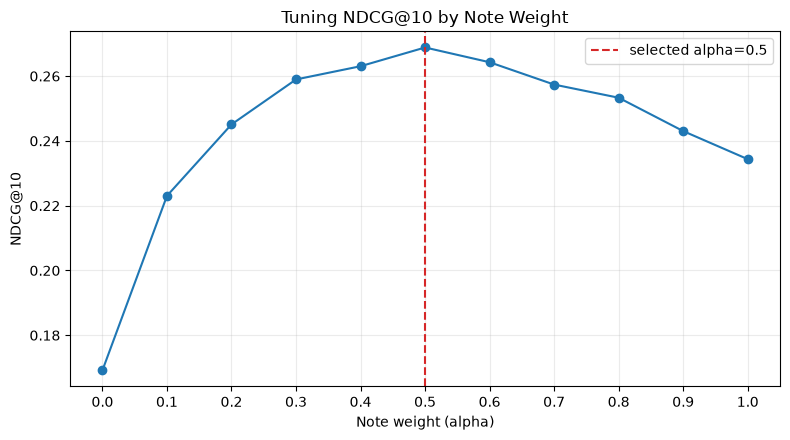

In [8]:
alphas = np.round(np.arange(0.0, 1.01, 0.1), 1)
alpha_rankings = {float(alpha): {} for alpha in alphas}

for start in tqdm(range(0, len(tuning_rows), BATCH_SIZE), desc="Alpha search"):
    query_rows = tuning_rows[start:start + BATCH_SIZE]
    query_ids = tuning_query_ids[start:start + BATCH_SIZE]
    raw_a, idf_a, raw_n, idf_n = similarity_batch(query_rows)
    accord_scores = idf_a if use_idf_accord else raw_a
    note_scores = idf_n if use_idf_note else raw_n
    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        for alpha in alphas:
            scores = float(alpha) * note_scores[i] + (1.0 - float(alpha)) * accord_scores[i]
            scores[query_row] = -np.inf
            alpha_rankings[float(alpha)][query_id] = top_k_rows(scores, 10)
    del raw_a, idf_a, raw_n, idf_n

alpha_rows = []
for alpha in alphas:
    summary, _ = evaluate_rankings(alpha_rankings[float(alpha)], tuning_query_ids, ks=(10,))
    alpha_rows.append({"alpha": float(alpha), **summary})
alpha_results_df = pd.DataFrame(alpha_rows)[
    ["alpha", "Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
]
display(alpha_results_df.round(4))

selected_alpha_row = alpha_results_df.sort_values(
    ["NDCG@10", "Recall@10", "MRR@10", "alpha"],
    ascending=[False, False, False, True],
).iloc[0]
selected_alpha = float(selected_alpha_row["alpha"])
print(f"Tuning Set에서 선택된 후보 가중치: Note={selected_alpha:.1f}, Accord={1-selected_alpha:.1f}")

plt.figure(figsize=(8, 4.5))
plt.plot(alpha_results_df["alpha"], alpha_results_df["NDCG@10"], marker="o")
plt.axvline(selected_alpha, color="tab:red", linestyle="--", label=f"selected alpha={selected_alpha:.1f}")
plt.xlabel("Note weight (alpha)")
plt.ylabel("NDCG@10")
plt.title("Tuning NDCG@10 by Note Weight")
plt.xticks(alphas)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Internal Validation 평가

이제 모든 선택을 고정한다. Internal Validation 200개에서는 다음 두 모델만 비교한다.

1. Original Baseline: Raw Accord + Raw Note, alpha=0.5
2. Selected Improved Model: Tuning에서 선택한 feature 표현과 alpha

이 결과를 본 뒤 선택을 수정하지 않는다.

In [9]:
validation_rankings = {"Original Baseline": {}, "Selected Improved Model": {}}
validation_rows = np.array([id_to_row[int(q)] for q in validation_query_ids], dtype=np.int32)

for start in tqdm(range(0, len(validation_rows), BATCH_SIZE), desc="Internal validation"):
    query_rows = validation_rows[start:start + BATCH_SIZE]
    query_ids = validation_query_ids[start:start + BATCH_SIZE]
    raw_a, idf_a, raw_n, idf_n = similarity_batch(query_rows)
    selected_a = idf_a if use_idf_accord else raw_a
    selected_n = idf_n if use_idf_note else raw_n
    for i, (query_id, query_row) in enumerate(zip(query_ids, query_rows)):
        query_id, query_row = int(query_id), int(query_row)
        baseline_scores = 0.5 * raw_a[i] + 0.5 * raw_n[i]
        improved_scores = selected_alpha * selected_n[i] + (1.0 - selected_alpha) * selected_a[i]
        baseline_scores[query_row] = -np.inf
        improved_scores[query_row] = -np.inf
        validation_rankings["Original Baseline"][query_id] = top_k_rows(baseline_scores, MAX_K)
        validation_rankings["Selected Improved Model"][query_id] = top_k_rows(improved_scores, MAX_K)
    del raw_a, idf_a, raw_n, idf_n

validation_summary_rows, validation_per_query = [], {}
for model_name, model_rankings in validation_rankings.items():
    summary, detail = evaluate_rankings(model_rankings, validation_query_ids, ks=(5, 10, 20))
    validation_per_query[model_name] = detail
    validation_summary_rows.append({"model": model_name, **summary})
validation_results_full_df = pd.DataFrame(validation_summary_rows)

display(validation_results_full_df[
    ["model", "Recall@5", "Recall@10", "Recall@20", "HitRate@10", "MRR@10", "NDCG@10", "NDCG@20"]
].round(4))
display(Markdown("### 표 2 — Internal Validation"))
validation_results_df = validation_results_full_df[
    ["model", "Recall@10", "HitRate@10", "MRR@10", "NDCG@10", "Recall@20", "NDCG@20"]
]
display(validation_results_df.round(4))
print("Final Holdout 평가 query 수: 0")

Internal validation:   0%|          | 0/13 [00:00<?, ?it/s]

,model,Recall@5,Recall@10,Recall@20,HitRate@10,MRR@10,NDCG@10,NDCG@20
0,Original Baseline,0.2418,0.3046,0.3719,0.580,0.3641,0.2659,0.2899
1,Selected Improved Model,0.2480,0.3270,0.3765,0.615,0.3742,0.2760,0.2942


### 표 2 — Internal Validation

,model,Recall@10,HitRate@10,MRR@10,NDCG@10,Recall@20,NDCG@20
0,Original Baseline,0.3046,0.580,0.3641,0.2659,0.3719,0.2899
1,Selected Improved Model,0.3270,0.615,0.3742,0.2760,0.3765,0.2942


Final Holdout 평가 query 수: 0


## 10. Internal Validation 개선폭

Selected Improved Model − Original Baseline의 absolute difference와 relative improvement를 계산한다.
Baseline이 0이면 relative improvement는 NaN이다.

In [10]:
comparison_metrics = ["Recall@10", "HitRate@10", "MRR@10", "NDCG@10"]
baseline_validation = validation_results_full_df.set_index("model").loc["Original Baseline"]
improved_validation = validation_results_full_df.set_index("model").loc["Selected Improved Model"]
improvement_rows = []
for metric in comparison_metrics:
    baseline_value, improved_value = baseline_validation[metric], improved_validation[metric]
    absolute = improved_value - baseline_value
    relative = absolute / baseline_value * 100 if baseline_value != 0 else np.nan
    improvement_rows.append({
        "metric": metric, "baseline": baseline_value, "improved": improved_value,
        "absolute_difference": absolute, "relative_improvement_%": relative,
    })
improvement_df = pd.DataFrame(improvement_rows)
improvement_df.round(4)

,metric,baseline,improved,absolute_difference,relative_improvement_%
0,Recall@10,0.3046,0.3270,0.0224,7.3559
1,HitRate@10,0.5800,0.6150,0.0350,6.0345
2,MRR@10,0.3641,0.3742,0.0100,2.7554
3,NDCG@10,0.2659,0.2760,0.0102,3.8296


## 11. Paired Bootstrap

Internal Validation의 동일 query별 Recall@10과 NDCG@10 차이를 seed 42, 2,000회 paired bootstrap한다.
CI가 0을 포함하지 않을 때에만 “개선 방향이 안정적임을 확인”이라고 표현한다.

In [11]:
def metric_vector(model_name, metric_name, k=10):
    detail = validation_per_query[model_name]
    indexed = detail[detail["k"] == k].set_index("query_id")
    return np.array([indexed.loc[int(q), metric_name] for q in validation_query_ids], dtype=float)

bootstrap_rng = np.random.default_rng(SEED)
bootstrap_rows = []
for display_name, metric_name in (("Recall@10", "recall"), ("NDCG@10", "ndcg")):
    differences = (
        metric_vector("Selected Improved Model", metric_name)
        - metric_vector("Original Baseline", metric_name)
    )
    indices = bootstrap_rng.integers(0, len(differences), size=(BOOTSTRAP_RESAMPLES, len(differences)))
    bootstrap_means = differences[indices].mean(axis=1)
    lower, upper = np.quantile(bootstrap_means, [0.025, 0.975])
    includes_zero = bool(lower <= 0 <= upper)
    bootstrap_rows.append({
        "metric": display_name, "mean_difference": differences.mean(),
        "ci_2.5%": lower, "ci_97.5%": upper, "CI_includes_zero": includes_zero,
        "interpretation": (
            "개선 방향이 안정적임을 확인" if not includes_zero and lower > 0
            else "95% CI가 0을 포함하므로 개선 방향의 안정성을 확인하지 못함"
        ),
    })
bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.round(4)

,metric,mean_difference,ci_2.5%,ci_97.5%,CI_includes_zero,interpretation
0,Recall@10,0.0224,0.0076,0.0397,False,개선 방향이 안정적임을 확인
1,NDCG@10,0.0102,0.0001,0.0205,False,개선 방향이 안정적임을 확인


## 12. 인기 향수 영향 Robustness 분석

Internal Validation query를 `popularity.magnitude`의 가능한 4분위(Q1~Q4)로 나누고 두 모델의
Recall@10/NDCG@10을 비교한다. 결측 query는 제외한다. 4개 분위 생성이 불가능하거나 한 그룹이 20개
미만이면 억지로 해석하지 않고 그 이유를 출력한다.

In [12]:
popularity_frame = pd.DataFrame({
    "query_id": validation_query_ids.astype(int),
    "popularity": [popularity[id_to_row[int(q)]] for q in validation_query_ids],
}).dropna()

robustness_df = pd.DataFrame()
robustness_interpretation = "분석하지 않음"
if popularity_frame["popularity"].nunique() < 4:
    robustness_interpretation = "고유 popularity 값이 4개 미만이라 4분위 분석을 수행하지 않음"
    print(robustness_interpretation)
else:
    try:
        popularity_frame["quartile"] = pd.qcut(
            popularity_frame["popularity"], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="raise"
        )
        quartile_counts = popularity_frame["quartile"].value_counts(sort=False)
        if (quartile_counts < MIN_GROUP_SIZE).any():
            robustness_interpretation = (
                f"그룹 크기가 {MIN_GROUP_SIZE}개 미만인 분위가 있어 성능 평균을 해석하지 않음: "
                + quartile_counts.to_dict().__repr__()
            )
            print(robustness_interpretation)
        else:
            lookup = popularity_frame.set_index("query_id")["quartile"]
            group_rows = []
            for quartile in ["Q1", "Q2", "Q3", "Q4"]:
                ids = [int(q) for q in validation_query_ids if q in lookup.index and lookup.loc[int(q)] == quartile]
                row = {"popularity_quartile": quartile, "query_count": len(ids)}
                for model_name, short_name in (
                    ("Original Baseline", "Baseline"), ("Selected Improved Model", "Improved")
                ):
                    detail = validation_per_query[model_name]
                    part = detail[(detail["k"] == 10) & detail["query_id"].isin(ids)]
                    row[f"{short_name} Recall@10"] = part["recall"].mean()
                    row[f"{short_name} NDCG@10"] = part["ndcg"].mean()
                group_rows.append(row)
            robustness_df = pd.DataFrame(group_rows)
            display(robustness_df.round(4))
            gains = robustness_df["Improved NDCG@10"] - robustness_df["Baseline NDCG@10"]
            robustness_interpretation = (
                "개선이 한 인기 그룹에만 집중됨" if (gains > 0).sum() <= 1
                else "개선이 한 인기 그룹에만 집중되지는 않음"
            )
            print(robustness_interpretation)
    except ValueError as exc:
        robustness_interpretation = f"동일 경계값 때문에 4개 분위 생성이 불가능하여 분석하지 않음: {exc}"
        print(robustness_interpretation)

,popularity_quartile,query_count,Baseline Recall@10,Baseline NDCG@10,Improved Recall@10,Improved NDCG@10
0,Q1,50,0.3300,0.2694,0.3583,0.2860
1,Q2,50,0.2163,0.2002,0.2480,0.2166
2,Q3,50,0.3431,0.2986,0.3531,0.2944
3,Q4,50,0.3288,0.2953,0.3484,0.3072


개선이 한 인기 그룹에만 집중되지는 않음


## 13. 사람이 확인할 샘플

Internal Validation에서 seed 42로 10개 query를 뽑아 실제 relevant item과 두 모델 TOP 5를 표시한다.
각 추천에는 `is_relevant` boolean을 붙이고, Baseline은 놓쳤지만 개선 모델은 찾은 query도 최대 5개 제시한다.

In [13]:
def perfume_label(perfume_id):
    row = id_to_row[int(perfume_id)]
    return f"{perfume_names[row]} — {perfume_brands[row]}"

def recommendation_table(query_id, model_name, k=5):
    relevant_ids = relevant_by_query[int(query_id)]
    rows = validation_rankings[model_name][int(query_id)][:k]
    return pd.DataFrame({
        "rank": np.arange(1, len(rows) + 1),
        "perfume": [perfume_names[row] for row in rows],
        "brand": [perfume_brands[row] for row in rows],
        "is_relevant": [int(perfume_ids[row]) in relevant_ids for row in rows],
    })

sample_rng = np.random.default_rng(SEED)
sample_query_ids = sample_rng.choice(validation_query_ids, size=10, replace=False)
for query_id in sample_query_ids:
    query_id = int(query_id)
    relevant_labels = [perfume_label(x) for x in sorted(relevant_by_query[query_id])]
    display(Markdown(
        f"### Query: {perfume_label(query_id)} (`id={query_id}`)\n\n"
        f"**실제 relevant item:** {', '.join(relevant_labels)}"
    ))
    for model_name in ("Original Baseline", "Selected Improved Model"):
        display(Markdown(f"**{model_name} TOP 5**"))
        display(recommendation_table(query_id, model_name, 5))

baseline_miss_improved_hit = []
for query_id in validation_query_ids:
    query_id = int(query_id)
    relevant = relevant_by_query[query_id]
    baseline_hit = any(int(perfume_ids[r]) in relevant for r in validation_rankings["Original Baseline"][query_id][:5])
    improved_hit = any(int(perfume_ids[r]) in relevant for r in validation_rankings["Selected Improved Model"][query_id][:5])
    if not baseline_hit and improved_hit:
        baseline_miss_improved_hit.append(query_id)

display(Markdown("### Baseline은 놓쳤지만 개선 모델은 찾은 Query (최대 5개)"))
if baseline_miss_improved_hit:
    for query_id in baseline_miss_improved_hit[:5]:
        display(Markdown(f"**Query: {perfume_label(query_id)} (`id={query_id}`)**"))
        display(recommendation_table(query_id, "Original Baseline", 5))
        display(recommendation_table(query_id, "Selected Improved Model", 5))
else:
    print("해당 조건의 query가 없습니다.")

### Query: Vintage Radio — Lattafa Perfumes (`id=89454`)

**실제 relevant item:** Paragon — Initio Parfums Prives, Al Nashama — Lattafa Perfumes, Paradigm — French Avenue

**Original Baseline TOP 5**

,rank,perfume,brand,is_relevant
0,1,Paragon,Initio Parfums Prives,True
1,2,Indomitable Spirit,Ainash Parfums,False
2,3,Flower of life Paragons,Artenisia,False
3,4,Born Original for Him,Adidas,False
4,5,Amir,Prince Parfums Dubai,False


**Selected Improved Model TOP 5**

,rank,perfume,brand,is_relevant
0,1,Paragon,Initio Parfums Prives,True
1,2,Indomitable Spirit,Ainash Parfums,False
2,3,Flower of life Paragons,Artenisia,False
3,4,Bois de Santal,Karl Lagerfeld,False
4,5,Born Original for Him,Adidas,False


...

,rank,perfume,brand,is_relevant
0,1,Santal Bloom,Saltair,False
1,2,Dubai Black,Rasayel Oud,False
2,3,Vacation Vibe,Bath & Body Works,False
3,4,Pink Cashmere,Bath & Body Works,False
4,5,Samba Ice Woman,Perfumer's Workshop,False


,rank,perfume,brand,is_relevant
0,1,Dubai Black,Rasayel Oud,False
1,2,Fields at Nightfall 2018,Zara,True
2,3,Arabia Malaak,Le Chameau,False
3,4,Vacation Vibe,Bath & Body Works,False
4,5,Santal Bloom,Saltair,False


**Query: Tahiti Island Dream — Bath & Body Works (`id=31098`)**

,rank,perfume,brand,is_relevant
0,1,Wild Petals,Emanuel Ungaro,False
1,2,Eve Confidence,Avon,False
2,3,Musk Collection Glam,Ulric de Varens,False
3,4,Kiaana Vibes,Afnan,False
4,5,Vanille Pitahaya,Comptoir Sud Pacifique,False


,rank,perfume,brand,is_relevant
0,1,Tahiti Island Dream,Bath & Body Works,True
1,2,Wild Petals,Emanuel Ungaro,False
2,3,Musk Collection Glam,Ulric de Varens,False
3,4,Cuide-se Bem Sol e Água Fresca,O Boticário,False
4,5,Eve Confidence,Avon,False


## 14. 최종 요약

아래 값은 Tuning에서 선택하고 Internal Validation에서 한 번 확인한 결과다. Final Holdout은 여전히 미사용이다.

In [14]:
single_lookup = single_results_df.set_index("model")
raw_note_ndcg = single_lookup.loc["Raw Note", "NDCG@10"]
idf_note_ndcg = single_lookup.loc["IDF Note", "NDCG@10"]
raw_accord_ndcg = single_lookup.loc["Raw Accord", "NDCG@10"]
idf_accord_ndcg = single_lookup.loc["IDF Accord", "NDCG@10"]

bootstrap_lookup = bootstrap_df.set_index("metric")
recall_ci = bootstrap_lookup.loc["Recall@10"]
ndcg_ci = bootstrap_lookup.loc["NDCG@10"]

summary_markdown = f"""
## 기존 Baseline

- Recall@10: {baseline_validation['Recall@10']:.4f}
- HitRate@10: {baseline_validation['HitRate@10']:.4f}
- MRR@10: {baseline_validation['MRR@10']:.4f}
- NDCG@10: {baseline_validation['NDCG@10']:.4f}

## IDF Ablation

- Note IDF 효과: NDCG@10 {raw_note_ndcg:.4f} → {idf_note_ndcg:.4f} (Tuning 단독 feature)
- Accord IDF 효과: NDCG@10 {raw_accord_ndcg:.4f} → {idf_accord_ndcg:.4f} (Tuning 단독 feature)
- 둘을 함께 적용했을 때 효과: Tuning Ablation 선택 표현은 **{selected_feature_model}**

## 가중치 탐색

- Tuning에서 선택한 Note 비중: {selected_alpha:.1f}
- Tuning에서 선택한 Accord 비중: {1-selected_alpha:.1f}
- 0.5 / 0.5 대비 차이: Note {selected_alpha-0.5:+.1f}, Accord {(1-selected_alpha)-0.5:+.1f}

## Internal Validation

- Recall@10: {improved_validation['Recall@10']:.4f}
- HitRate@10: {improved_validation['HitRate@10']:.4f}
- MRR@10: {improved_validation['MRR@10']:.4f}
- NDCG@10: {improved_validation['NDCG@10']:.4f}
- 기존 Baseline 대비 개선: NDCG@10 {improved_validation['NDCG@10']-baseline_validation['NDCG@10']:+.4f}

## 안정성

- Recall@10 bootstrap CI: [{recall_ci['ci_2.5%']:.4f}, {recall_ci['ci_97.5%']:.4f}] (0 포함: {recall_ci['CI_includes_zero']})
- NDCG@10 bootstrap CI: [{ndcg_ci['ci_2.5%']:.4f}, {ndcg_ci['ci_97.5%']:.4f}] (0 포함: {ndcg_ci['CI_includes_zero']})
- 인기 향수 그룹에만 개선이 집중되는지: {robustness_interpretation}

## 현재 판단

- IDF를 유지할지: Note/Accord 각각의 Tuning ablation과 Validation 결과를 함께 보고 판단
- Accord / Note 가중치: 후보 Note {selected_alpha:.1f} / Accord {1-selected_alpha:.1f}
- 개선이 재현되는지: paired bootstrap CI와 popularity quartile 결과 기준으로 해석
- 다음 Ablation 후보: Season/Daypart 등을 한 번에 추가하지 말고, 다음 단계에서도 한 요소씩 검증
"""
display(Markdown(summary_markdown))
print("Final Holdout은 끝까지 평가하지 않았습니다.")


## 기존 Baseline

- Recall@10: 0.3046
- HitRate@10: 0.5800
- MRR@10: 0.3641
- NDCG@10: 0.2659

## IDF Ablation

- Note IDF 효과: NDCG@10 0.2372 → 0.2344 (Tuning 단독 feature)
- Accord IDF 효과: NDCG@10 0.1692 → 0.1676 (Tuning 단독 feature)
- 둘을 함께 적용했을 때 효과: Tuning Ablation 선택 표현은 **Raw Accord + IDF Note**

## 가중치 탐색

- Tuning에서 선택한 Note 비중: 0.5
- Tuning에서 선택한 Accord 비중: 0.5
- 0.5 / 0.5 대비 차이: Note +0.0, Accord +0.0

## Internal Validation

- Recall@10: 0.3270
- HitRate@10: 0.6150
- MRR@10: 0.3742
- NDCG@10: 0.2760
- 기존 Baseline 대비 개선: NDCG@10 +0.0102

## 안정성

- Recall@10 bootstrap CI: [0.0076, 0.0397] (0 포함: False)
- NDCG@10 bootstrap CI: [0.0001, 0.0205] (0 포함: False)
- 인기 향수 그룹에만 개선이 집중되는지: 개선이 한 인기 그룹에만 집중되지는 않음

## 현재 판단

- IDF를 유지할지: Note/Accord 각각의 Tuning ablation과 Validation 결과를 함께 보고 판단
- Accord / Note 가중치: 후보 Note 0.5 / Accord 0.5
- 개선이 재현되는지: paired bootstrap CI와 popularity quartile 결과 기준으로 해석
- 다음 Ablation 후보: Season/Daypart 등을 한 번에 추가하지 말고, 다음 단계에서도 한 요소씩 검증


Final Holdout은 끝까지 평가하지 않았습니다.


## 기존 Baseline

- Recall@10: 0.3046
- HitRate@10: 0.5800
- MRR@10: 0.3641
- NDCG@10: 0.2659

## IDF Ablation

- Note IDF 효과: 단독 NDCG@10은 0.2372 → 0.2344로 낮아졌지만, Raw Accord와 결합하면 0.2671 → 0.2688로 소폭 개선
- Accord IDF 효과: 단독 NDCG@10은 0.1692 → 0.1676, Raw Note와 결합하면 0.2671 → 0.2603으로 하락
- 둘을 함께 적용했을 때 효과: NDCG@10 0.2592로 Raw/Raw 0.2671보다 하락

## 가중치 탐색

- Tuning에서 선택한 Note 비중: 0.5
- Tuning에서 선택한 Accord 비중: 0.5
- 0.5 / 0.5 대비 차이: 없음

## Internal Validation

- Recall@10: 0.3270
- HitRate@10: 0.6150
- MRR@10: 0.3742
- NDCG@10: 0.2760
- 기존 Baseline 대비 개선: Recall@10 +0.0224, HitRate@10 +0.0350, MRR@10 +0.0100, NDCG@10 +0.0102

## 안정성

- Recall@10 bootstrap CI: [0.0076, 0.0397], 0 미포함
- NDCG@10 bootstrap CI: [0.0001, 0.0205], 0 미포함
- 인기 향수 그룹에만 개선이 집중되는지: Q1, Q2, Q4에서 NDCG@10이 개선되고 Q3에서는 소폭 하락하여 한 그룹에만 집중되지는 않음

## 현재 판단

- IDF를 유지할지: Note IDF는 유지할 후보이며 Accord IDF는 제외
- Accord / Note 가중치: 0.5 / 0.5 유지
- 개선이 재현되는지: Internal Validation에서 네 핵심 지표가 모두 개선됐고 두 bootstrap CI가 0을 포함하지 않아 개선 방향이 재현됨. 다만 NDCG@10 하한이 0.0001로 효과 크기는 보수적으로 해석
- 다음 Ablation 후보: Top/Middle/Base Note 위치 가중치를 한 요소로만 추가 검증

Final Holdout 300개는 평가하지 않았고, `reminds_me_of`는 Relevant Item label로만 사용했다.